# Project 2: Fraud Detection Pipeline (Leak-Free)
**DecodeLabs Industrial Training Kit — Supervised Learning**

Goal: Build a classification model to detect fraudulent transactions in a highly imbalanced dataset, using SMOTE for resampling, without any data leakage.

**Dataset:** Kaggle "Credit Card Fraud Detection" (`creditcard.csv`) — 284,807 transactions, ~0.17% fraud.

Steps: EDA → Stratified Split → Imblearn Pipeline (Scaler + SMOTE + Model) → GridSearchCV → Evaluation (Precision/Recall/ROC-AUC).

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2. Load Data
Download `creditcard.csv` from Kaggle (Credit Card Fraud Detection dataset) and place it in the same folder, or update the path below.

In [4]:
DATA_PATH = 'creditcard.csv'  # <-- update this path if needed

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Missing values
print('Missing values:\n', df.isnull().sum().sum())

# Class distribution
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print('\nClass counts:\n', class_counts)
print('\nClass %:\n', class_pct)

Missing values:
 0

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class %:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


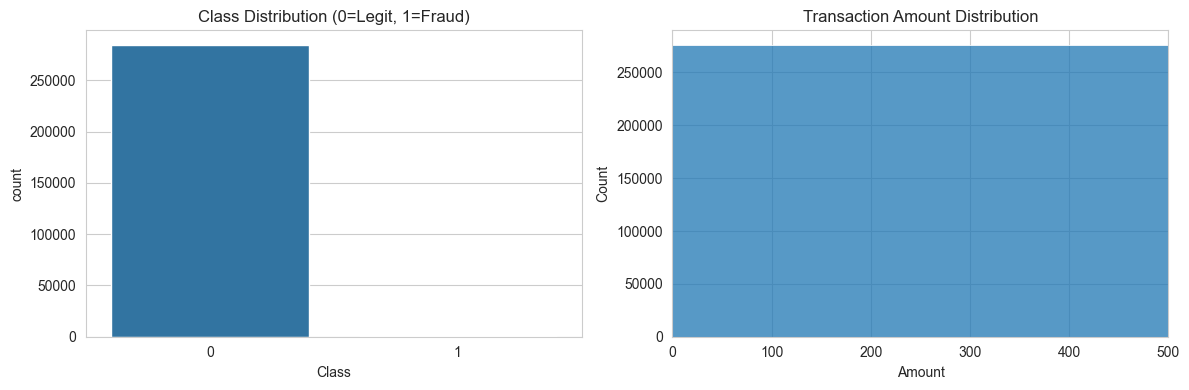

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Class', data=df, ax=axes[0])
axes[0].set_title('Class Distribution (0=Legit, 1=Fraud)')

sns.histplot(df['Amount'], bins=50, ax=axes[1])
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

## 4. Train/Test Split — BEFORE any scaling or SMOTE
This is the golden rule: split first, resample/scale only inside the training fold. Stratify to preserve the extreme imbalance in both sets.

In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape, 'Fraud rate:', y_train.mean())
print('Test shape:', X_test.shape, 'Fraud rate:', y_test.mean())

Train shape: (227845, 30) Fraud rate: 0.001729245759178389
Test shape: (56962, 30) Fraud rate: 0.0017204452090867595


## 5. Build Leak-Free Pipelines (imblearn, NOT sklearn)
- Logistic Regression needs a scaler (sensitive to feature scale).
- Random Forest doesn't need scaling (tree splits are scale-invariant).

In [8]:
# Logistic Regression pipeline
lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Random Forest pipeline
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

## 6. Hyperparameter Tuning with GridSearchCV
SMOTE is applied fresh inside every fold for every parameter combination — zero leakage.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression grid ---
lr_param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__C': [0.01, 0.1, 1.0]
}

lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1
)
lr_grid.fit(X_train, y_train)
print('Best LR params:', lr_grid.best_params_)
print('Best LR CV ROC-AUC:', lr_grid.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best LR params: {'classifier__C': 0.01, 'smote__k_neighbors': 5}
Best LR CV ROC-AUC: 0.9807276092904393


In [10]:
rf_param_grid = {
    'smote__k_neighbors': [5],
    'classifier__n_estimators': [50],
    'classifier__max_depth': [10]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
print('Best RF params:', rf_grid.best_params_)
print('Best RF CV ROC-AUC:', rf_grid.best_score_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best RF params: {'classifier__max_depth': 10, 'classifier__n_estimators': 50, 'smote__k_neighbors': 5}
Best RF CV ROC-AUC: 0.9820257385780892


## 7. Final Evaluation on Untouched Test Set
The test set was never scaled or resampled — it reflects the real-world 0.17% fraud rate.


===== Logistic Regression =====
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9714607283543693


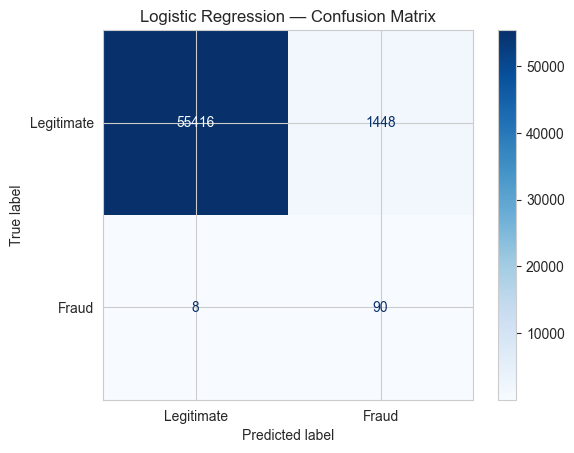


===== Random Forest =====
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.51      0.89      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9853427583751565


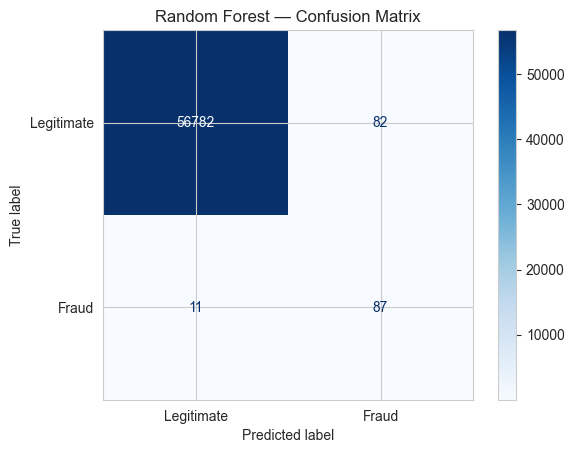

In [11]:
def evaluate_model(name, grid, X_test, y_test):
    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]

    print(f'\n===== {name} =====')
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
    print('ROC-AUC:', roc_auc_score(y_test, y_proba))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.show()

    return y_proba

lr_proba = evaluate_model('Logistic Regression', lr_grid, X_test, y_test)
rf_proba = evaluate_model('Random Forest', rf_grid, X_test, y_test)

## 8. Compare ROC Curves

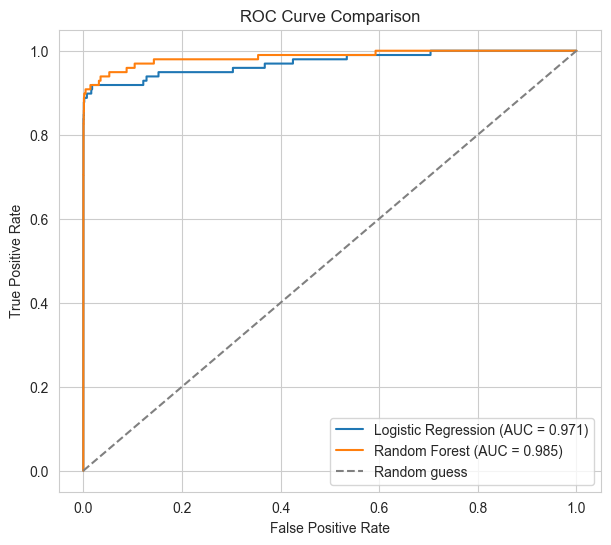

In [12]:
plt.figure(figsize=(7, 6))

for name, proba in [('Logistic Regression', lr_proba), ('Random Forest', rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 9. Notes / Next Steps
- Try `RandomUnderSampler` or `SMOTEENN` as alternative resampling strategies and compare.
- Tune the decision threshold (not just 0.5) using the precision-recall curve — in fraud detection, recall is often prioritized over precision.
- Log every false positive/negative case for manual review — treat them as learning signals, as the training kit suggests.
- Push final notebook + a short README to GitHub for your portfolio (same as Project 01).